<div style="
  font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Arial, sans-serif;
  line-height: 1.55;
  color: var(--vscode-editor-foreground);
">

<h2 style="margin-bottom: 6px;">Day 9 — Notebook 3</h2>
<h3 style="margin-top: 0;">Bagging, Random Forest, RSM, OOB, and Feature Importance</h3>

<p>
This notebook continues the Day 9 Ensemble Learning project using the prepared
Bank Marketing train/test data from Notebook 2.
</p>

<div style="
  border-left: 4px solid #38bdf8;
  padding: 10px 14px;
  margin: 12px 0;
  background: var(--vscode-editorWidget-background);
  border-radius: 6px;
">
  <b>Short theory reminder:</b><br>
  <b>Bagging</b> gives each tree different rows through bootstrap sampling.<br>
  <b>RSM</b> gives each tree/split different feature subsets.<br>
  <b>Random Forest</b> combines bagging + RSM + many decision trees + voting.
</div>

<p>
The goal is to check whether Random Forest improves over a single Decision Tree and
whether the extra forest complexity gives useful business value compared with the strong
Logistic Regression baseline from Notebook 2.
</p>

</div>

<div style="
  font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Arial, sans-serif;
  line-height: 1.55;
  color: var(--vscode-editor-foreground);
">

<h3 style="margin-bottom: 6px;">Important points for understanding</h3>

<ul>
  <li><b>Single Decision Tree:</b> easy to explain, but can overfit and become unstable.</li>
  <li><b>Random Forest:</b> many trees vote together, usually giving more stable predictions.</li>
  <li><b>Bootstrap rows:</b> each tree sees a different random row sample.</li>
  <li><b>Random feature subsets:</b> each tree/split does not always use all features.</li>
  <li><b>OOB score:</b> a built-in validation idea using rows not selected in a tree's bootstrap sample.</li>
  <li><b>Feature importance:</b> helps us explain which customer/campaign variables drive predictions.</li>
</ul>

</div>

In [1]:
# Core data handling libraries
import pandas as pd
import numpy as np

# Plotting library
import matplotlib.pyplot as plt

# File and model saving utilities
from pathlib import Path
import joblib

# Scikit-learn preprocessing tools
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

# Scikit-learn models
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Scikit-learn evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

# Notebook display setting for cleaner tables
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 120)

# Random seed keeps results reproducible.
RANDOM_STATE = 42


<div style="
  font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Arial, sans-serif;
  line-height: 1.55;
  color: var(--vscode-editor-foreground);
">

<h3 style="margin-bottom: 6px;">1. Load Notebook 2 outputs</h3>

<p>
Notebook 2 already created the train/test split and saved reusable outputs.
Here we load those files instead of repeating the full data preparation process.
</p>

</div>

In [2]:
# Define project folders used across Day 9 notebooks.
# These should already exist after running Notebook 2.

data_dir = Path("data")
processed_dir = data_dir / "processed"
reports_dir = Path("reports")
models_dir = Path("models")
figures_dir = Path("figures")

# Create output folders if they do not exist yet.
# This makes the notebook safe to run even if some output folders are missing.

reports_dir.mkdir(exist_ok=True)
models_dir.mkdir(exist_ok=True)
figures_dir.mkdir(exist_ok=True)

# Define expected input files from Notebook 2.

x_train_path = processed_dir / "day9_X_train_raw.csv"
x_test_path = processed_dir / "day9_X_test_raw.csv"
y_train_path = processed_dir / "day9_y_train.csv"
y_test_path = processed_dir / "day9_y_test.csv"
baseline_results_path = reports_dir / "day9_baseline_model_results.csv"

# Check that all required files exist before loading.

required_files = [
    x_train_path,
    x_test_path,
    y_train_path,
    y_test_path,
    baseline_results_path,
]

missing_files = [file_path for file_path in required_files if not file_path.exists()]

if missing_files:
    raise FileNotFoundError(
        "Notebook 3 needs outputs from Notebook 2. "
        "Please run Notebook 2 first. Missing files:\n"
        + "\n".join(str(file_path) for file_path in missing_files)
    )

# Load train/test feature tables.
# These are raw feature tables before preprocessing.

X_train = pd.read_csv(x_train_path)
X_test = pd.read_csv(x_test_path)

# Load target vectors and convert them to Series.
# The target is binary: 0 = Not subscribed, 1 = Subscribed.

y_train = pd.read_csv(y_train_path).squeeze("columns")
y_test = pd.read_csv(y_test_path).squeeze("columns")

# Load baseline results from Notebook 2 for comparison.

baseline_results = pd.read_csv(baseline_results_path)

print("Notebook 2 outputs loaded successfully.")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape:  {y_test.shape}")

display(baseline_results)


Notebook 2 outputs loaded successfully.
X_train shape: (8929, 16)
X_test shape:  (2233, 16)
y_train shape: (8929,)
y_test shape:  (2233,)


,Model,Accuracy,Precision,Recall,F1_Score,ROC_AUC
0,Logistic Regression,0.8289,0.8207,0.8176,0.8191,0.9071
1,KNN,0.8173,0.8199,0.7873,0.8033,0.8796
2,Decision Tree,0.7944,0.7894,0.7722,0.7807,0.7933
3,Dummy Majority Baseline,0.5262,0.0000,0.0000,0.0000,0.5000


<div style="
  font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Arial, sans-serif;
  line-height: 1.55;
  color: var(--vscode-editor-foreground);
">

<h3 style="margin-bottom: 6px;">2. Rebuild preprocessing pipeline</h3>

<p>
The models need numeric and categorical features to be processed differently.
Numeric columns are imputed and scaled. Categorical columns are imputed and one-hot encoded.
</p>

<div style="
  border-left: 4px solid #38bdf8;
  padding: 10px 14px;
  margin: 12px 0;
  background: var(--vscode-editorWidget-background);
  border-radius: 6px;
">
  <b>Important point for understanding:</b><br>
  We fit preprocessing only on the training data inside the pipeline.
  This prevents information from the test set leaking into the model.
</div>

</div>

In [3]:
# Identify numeric and categorical feature columns from the raw training data.
# X_train contains only input features, not the target.

numeric_columns = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_columns = X_train.select_dtypes(exclude=["int64", "float64"]).columns.tolist()

print(f"Numeric columns ({len(numeric_columns)}): {numeric_columns}")
print(f"Categorical columns ({len(categorical_columns)}): {categorical_columns}")

# Numeric preprocessing:
# - Fill missing numeric values with the median.
# - Scale numeric values so distance-based models and linear models behave better.

numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

# Categorical preprocessing:
# - Fill missing categorical values with the most frequent category.
# - One-hot encode categories into numeric dummy columns.
#
# The try/except keeps this compatible with different scikit-learn versions.

try:
    one_hot_encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    one_hot_encoder = OneHotEncoder(handle_unknown="ignore", sparse=False)

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", one_hot_encoder),
])

# Combine numeric and categorical preprocessing into one ColumnTransformer.
# This object will be placed inside each model pipeline.

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_pipeline, numeric_columns),
        ("categorical", categorical_pipeline, categorical_columns),
    ],
    remainder="drop",
)


Numeric columns (7): ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
Categorical columns (9): ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']


# Helper Functions

In [6]:
# Helper function to extract readable feature names after preprocessing.
# This is needed for feature importance plots because one-hot encoding creates new columns.

def get_processed_feature_names(fitted_preprocessor):
    
    """
    Return feature names after numeric scaling and categorical one-hot encoding.

    Input:
    - fitted_preprocessor: a fitted ColumnTransformer

    Output:
    - list of processed feature names
    """
    try:
        feature_names = fitted_preprocessor.get_feature_names_out()
        feature_names = [name.replace("numeric__", "").replace("categorical__", "") for name in feature_names]
        return feature_names
    
    except Exception:
        
        # Fallback if get_feature_names_out is not available.
        
        numeric_feature_names = numeric_columns.copy()

        categorical_transformer = fitted_preprocessor.named_transformers_["categorical"]
        
        encoder = categorical_transformer.named_steps["encoder"]
        
        categorical_feature_names = encoder.get_feature_names_out(categorical_columns).tolist()

        return numeric_feature_names + categorical_feature_names


# Helper function to evaluate binary classification models consistently.

def evaluate_classifier(model_name, fitted_pipeline, X_train, X_test, y_train, y_test):
    
    """
    Calculate train and test metrics for a fitted classification pipeline.

    Input:
    
    - model_name: readable model name
    - fitted_pipeline: fitted sklearn Pipeline
    - X_train, X_test: feature tables
    - y_train, y_test: target vectors

    Output:
    - dictionary containing model performance metrics
    """
    
    # Predictions for train and test sets.
    
    train_pred = fitted_pipeline.predict(X_train)
    test_pred = fitted_pipeline.predict(X_test)

    # Probability predictions for ROC-AUC.
    
    # Class 1 means customer subscribed.
    if hasattr(fitted_pipeline.named_steps["model"], "predict_proba"):
        train_proba = fitted_pipeline.predict_proba(X_train)[:, 1]
        test_proba = fitted_pipeline.predict_proba(X_test)[:, 1]
        train_roc_auc = roc_auc_score(y_train, train_proba)
        test_roc_auc = roc_auc_score(y_test, test_proba)
        
    else:
        train_roc_auc = np.nan
        test_roc_auc = np.nan

    # Return metrics in one clean row.
    
    return {
        "Model": model_name,
        "Train_Accuracy": accuracy_score(y_train, train_pred),
        "Test_Accuracy": accuracy_score(y_test, test_pred),
        "Train_F1": f1_score(y_train, train_pred, zero_division=0),
        "Test_F1": f1_score(y_test, test_pred, zero_division=0),
        "Test_Precision": precision_score(y_test, test_pred, zero_division=0),
        "Test_Recall": recall_score(y_test, test_pred, zero_division=0),
        "Train_ROC_AUC": train_roc_auc,
        "Test_ROC_AUC": test_roc_auc,
        "Accuracy_Gap": accuracy_score(y_train, train_pred) - accuracy_score(y_test, test_pred),
        "F1_Gap": f1_score(y_train, train_pred, zero_division=0) - f1_score(y_test, test_pred, zero_division=0),
    }


<div style="
  font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Arial, sans-serif;
  line-height: 1.55;
  color: var(--vscode-editor-foreground);
">

<h3 style="margin-bottom: 6px;">3. Single Decision Tree vs Random Forest</h3>

<p>
The MVD asks us to compare a full single Decision Tree with a Random Forest using
100 trees. This is the first practical test of whether bagging and random feature selection
improve over one unstable tree.
</p>

</div>

In [7]:
# Create the required MVD models:

# 1. DecisionTreeClassifier with max_depth=None
# 2. RandomForestClassifier with n_estimators=100

# Single Decision Tree:
# max_depth=None allows the tree to grow fully.
# This can give high train accuracy but may overfit.

single_tree_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(
        max_depth=None,
        random_state=RANDOM_STATE,
    )),
])

# Random Forest:
# 100 trees trained with bootstrap sampling and random feature subsets.
# n_jobs=-1 uses all available CPU cores.

random_forest_100_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=100,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )),
])

# Fit both models on the training data.

single_tree_pipeline.fit(X_train, y_train)
random_forest_100_pipeline.fit(X_train, y_train)

# Evaluate both models using the same metric function.

tree_forest_results = pd.DataFrame([
    evaluate_classifier("Single Decision Tree", single_tree_pipeline, X_train, X_test, y_train, y_test),
    evaluate_classifier("Random Forest (100 trees)", random_forest_100_pipeline, X_train, X_test, y_train, y_test),
])

# Create rounded display version.

tree_forest_results_rounded = tree_forest_results.copy()
metric_cols = [
    "Train_Accuracy", "Test_Accuracy",
    "Train_F1", "Test_F1",
    "Test_Precision", "Test_Recall",
    "Train_ROC_AUC", "Test_ROC_AUC",
    "Accuracy_Gap", "F1_Gap",
]

for col in metric_cols:
    tree_forest_results_rounded[col] = tree_forest_results_rounded[col].round(4)

display(tree_forest_results_rounded)


,Model,Train_Accuracy,Test_Accuracy,Train_F1,Test_F1,Test_Precision,Test_Recall,Train_ROC_AUC,Test_ROC_AUC,Accuracy_Gap,F1_Gap
0,Single Decision Tree,1.0,0.7944,1.0,0.7807,0.7894,0.7722,1.0,0.7933,0.2056,0.2193
1,Random Forest (100 trees),1.0,0.8621,1.0,0.8596,0.8301,0.8913,1.0,0.9193,0.1379,0.1404


<div style="
  font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Arial, sans-serif;
  line-height: 1.55;
  color: var(--vscode-editor-foreground);
">

<h3 style="margin-bottom: 6px;">Conclusion: Single Decision Tree vs Random Forest</h3>

<p>
The comparison shows a clear improvement from using a Random Forest instead of a single Decision Tree.
Both models achieved perfect training performance, but their test performance is very different.
</p>

<div style="
  border-left: 4px solid #f59e0b;
  padding: 10px 14px;
  margin: 12px 0;
  background: var(--vscode-editorWidget-background);
  border-radius: 6px;
">
  <b>Decision Tree result:</b><br>
  The single Decision Tree achieved <b>100% training accuracy</b>, but only
  <b>79.44% test accuracy</b> and <b>78.07% test F1-score</b>.
  This shows strong overfitting.
</div>

<div style="
  border-left: 4px solid #22c55e;
  padding: 10px 14px;
  margin: 12px 0;
  background: var(--vscode-editorWidget-background);
  border-radius: 6px;
">
  <b>Random Forest result:</b><br>
  Random Forest achieved <b>86.21% test accuracy</b>, <b>85.96% test F1-score</b>,
  and <b>91.93% test ROC-AUC</b>.
  It performs much better on unseen data than the single Decision Tree.
</div>

<p>
The Random Forest improved the test F1-score from <b>0.7807</b> to <b>0.8596</b>.
It also improved ROC-AUC from <b>0.7933</b> to <b>0.9193</b>.
This means the forest separates likely subscribers from non-subscribers much better than one tree.
</p>

<div style="
  border-left: 4px solid #38bdf8;
  padding: 10px 14px;
  margin: 12px 0;
  background: var(--vscode-editorWidget-background);
  border-radius: 6px;
">
  <b>Important point for understanding:</b><br>
  A single Decision Tree can memorize the training data.
  Random Forest reduces this instability by training many trees on different row samples and different feature subsets,
  then combining their predictions through voting.
</div>

<p>
From a business point of view, Random Forest is clearly more useful than a single Decision Tree for this campaign prediction task.
It catches more true subscribers while keeping overall prediction quality strong.
</p>

</div>

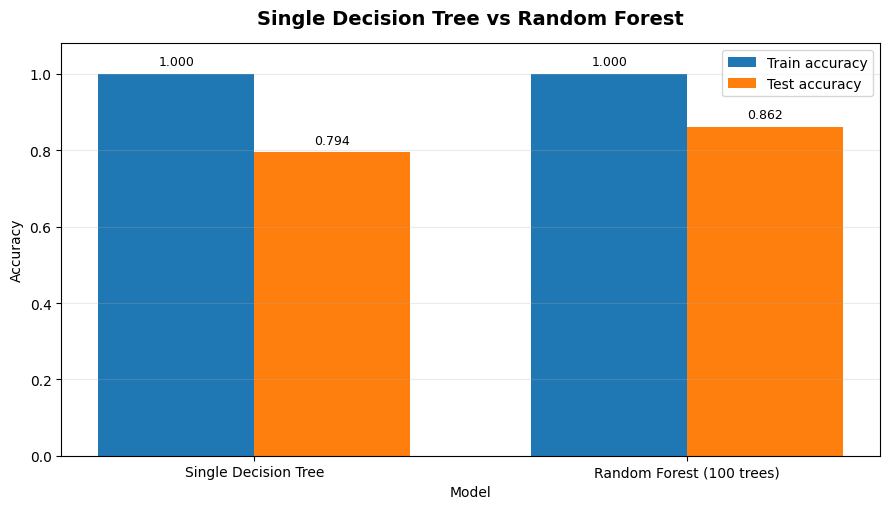

In [8]:
# Plot train vs test accuracy for the single tree and Random Forest.
# This helps us visually compare overfitting and generalization.

plot_data = tree_forest_results_rounded[["Model", "Train_Accuracy", "Test_Accuracy"]].copy()

x_positions = np.arange(len(plot_data))
bar_width = 0.36

plt.figure(figsize=(9, 5.2))

plt.bar(
    x_positions - bar_width / 2,
    plot_data["Train_Accuracy"],
    width=bar_width,
    label="Train accuracy",
)

plt.bar(
    x_positions + bar_width / 2,
    plot_data["Test_Accuracy"],
    width=bar_width,
    label="Test accuracy",
)

plt.title("Single Decision Tree vs Random Forest", fontsize=14, weight="bold", pad=14)
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.xticks(x_positions, plot_data["Model"], rotation=0)
plt.ylim(0, 1.08)
plt.grid(axis="y", alpha=0.25)
plt.legend()

# Add metric labels on bars.
for idx, row in plot_data.iterrows():
    plt.text(
        x_positions[idx] - bar_width / 2,
        row["Train_Accuracy"] + 0.015,
        f"{row['Train_Accuracy']:.3f}",
        ha="center",
        va="bottom",
        fontsize=9,
    )
    plt.text(
        x_positions[idx] + bar_width / 2,
        row["Test_Accuracy"] + 0.015,
        f"{row['Test_Accuracy']:.3f}",
        ha="center",
        va="bottom",
        fontsize=9,
    )

plt.tight_layout()
plt.savefig(figures_dir / "day9_tree_vs_random_forest_accuracy.png", dpi=150, bbox_inches="tight")
plt.show()


<div style="
  font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Arial, sans-serif;
  line-height: 1.55;
  color: var(--vscode-editor-foreground);
">

<h3 style="margin-bottom: 6px;">Result interpretation guide</h3>

<div style="
  border-left: 4px solid #f59e0b;
  padding: 10px 14px;
  margin: 12px 0;
  background: var(--vscode-editorWidget-background);
  border-radius: 6px;
">
  <b>What to look for:</b><br>
  If the single tree has very high train accuracy but lower test accuracy, it is overfitting.
  If Random Forest has a smaller train-test gap and stronger test results, bagging and feature randomness are helping.
</div>

<p>
After running the cell, write the actual numbers in the conclusion.
The business question is whether Random Forest gives more stable customer subscription predictions
than one single Decision Tree.
</p>

</div>

<div style="
  font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Arial, sans-serif;
  line-height: 1.55;
  color: var(--vscode-editor-foreground);
">

<h3 style="margin-bottom: 6px;">4. Feature importance: Tree vs Random Forest</h3>

<p>
The MVD asks whether the most important features agree between the single Decision Tree
and the Random Forest. This matters because feature importance is one way to explain
customer prediction drivers to business stakeholders.
</p>

</div>

In [9]:
# Extract processed feature names from the fitted preprocessing step.
# Both pipelines use a fitted preprocessor after model training.

tree_feature_names = get_processed_feature_names(single_tree_pipeline.named_steps["preprocessor"])
forest_feature_names = get_processed_feature_names(random_forest_100_pipeline.named_steps["preprocessor"])

# Extract feature importance values from the trained models.

tree_importance_values = single_tree_pipeline.named_steps["model"].feature_importances_
forest_importance_values = random_forest_100_pipeline.named_steps["model"].feature_importances_

# Build feature importance tables.

tree_feature_importance = (
    pd.DataFrame({
        "Feature": tree_feature_names,
        "Importance": tree_importance_values,
    })
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)

forest_feature_importance = (
    pd.DataFrame({
        "Feature": forest_feature_names,
        "Importance": forest_importance_values,
    })
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)

print("Top 10 features — Single Decision Tree")
display(tree_feature_importance.head(10))

print("\nTop 10 features — Random Forest")
display(forest_feature_importance.head(10))


Top 10 features — Single Decision Tree


,Feature,Importance
0,duration,0.341793
1,balance,0.075338
2,poutcome_success,0.071684
3,day,0.068466
4,contact_unknown,0.065205
5,age,0.062907
6,pdays,0.025610
7,campaign,0.022243
8,housing_yes,0.021873
9,month_mar,0.020236



Top 10 features — Random Forest


,Feature,Importance
0,duration,0.327869
1,balance,0.077540
2,age,0.073438
3,day,0.066317
4,campaign,0.034272
5,pdays,0.030631
6,poutcome_success,0.028859
7,contact_unknown,0.021852
8,previous,0.019865
9,contact_cellular,0.017546


<div style="
  font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Arial, sans-serif;
  line-height: 1.55;
  color: var(--vscode-editor-foreground);
">

<h3 style="margin-bottom: 6px;">Important Point: Extracting Feature Importance from Pipelines</h3>

<p>
This section extracts feature importance values from the trained <b>Decision Tree</b> and
<b>Random Forest</b> pipelines.
</p>

<p>
Each pipeline has two important parts:
</p>

<table style="border-collapse: collapse; width: 100%; margin: 10px 0;">
  <thead>
    <tr>
      <th style="text-align: left; border-bottom: 1px solid #888; padding: 6px;">Pipeline step</th>
      <th style="text-align: left; border-bottom: 1px solid #888; padding: 6px;">Meaning</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td style="padding: 6px;"><code>named_steps["preprocessor"]</code></td>
      <td style="padding: 6px;">The preprocessing part that scales numeric features and encodes categorical features.</td>
    </tr>
    <tr>
      <td style="padding: 6px;"><code>named_steps["model"]</code></td>
      <td style="padding: 6px;">The trained machine learning model inside the pipeline.</td>
    </tr>
  </tbody>
</table>

<p>
The helper function <code>get_processed_feature_names()</code> returns the final feature names after preprocessing.
This is needed because categorical columns are expanded into encoded columns such as
<code>contact_cellular</code>, <code>contact_unknown</code>, and <code>poutcome_success</code>.
</p>

<div style="
  border-left: 4px solid #38bdf8;
  padding: 10px 14px;
  margin: 12px 0;
  background: var(--vscode-editorWidget-background);
  border-radius: 6px;
">
  <b>Key idea:</b><br>
  <code>feature_importances_</code> gives only numeric importance values.
  To understand those values, we must match them with the processed feature names.
</div>

<p>
For the single tree pipeline, <code>named_steps["model"]</code> refers to the trained
<b>DecisionTreeClassifier</b>. For the Random Forest pipeline, it refers to the trained
<b>RandomForestClassifier</b>.
</p>

<p>
After extracting the feature names and importance values, we combine them into clean tables,
sort them from highest to lowest importance, and compare the top features from both models.
</p>

</div>

<div style="
  font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Arial, sans-serif;
  line-height: 1.55;
  color: var(--vscode-editor-foreground);
">

<h3 style="margin-bottom: 6px;">Conclusion: Feature Importance Comparison</h3>

<p>
The feature importance comparison shows that both the single Decision Tree and Random Forest agree on the most important feature:
<b>duration</b>. This means contact duration is the strongest signal for predicting whether a customer subscribes.
</p>

<div style="
  border-left: 4px solid #22c55e;
  padding: 10px 14px;
  margin: 12px 0;
  background: var(--vscode-editorWidget-background);
  border-radius: 6px;
">
  <b>Strong agreement:</b><br>
  Both models rank <b>duration</b> and <b>balance</b> as the top two features.
  Both models also use <b>day</b>, <b>age</b>, <b>campaign</b>, <b>pdays</b>,
  <b>poutcome_success</b>, and <b>contact type</b> as important predictors.
</div>

<p>
The single Decision Tree relies more heavily on a small number of features.
Random Forest spreads importance across more variables because it combines many trees trained on different row samples
and feature subsets.
This makes the Random Forest more stable and less dependent on one exact decision path.
</p>

<div style="
  border-left: 4px solid #f59e0b;
  padding: 10px 14px;
  margin: 12px 0;
  background: var(--vscode-editorWidget-background);
  border-radius: 6px;
">
  <b>Important business caution:</b><br>
  The feature <b>duration</b> is very predictive, but it is usually known only after the customer call has happened.
  For a real pre-campaign targeting model, we may need to build a second version without <b>duration</b>
  to avoid using information that is not available before the campaign contact.
</div>

<p>
From a business point of view, the models suggest that campaign interaction quality, customer balance,
age, previous campaign outcome, contact method, and campaign history all influence subscription prediction.
Random Forest gives a more balanced and reliable view of these drivers than a single Decision Tree.
</p>

</div>

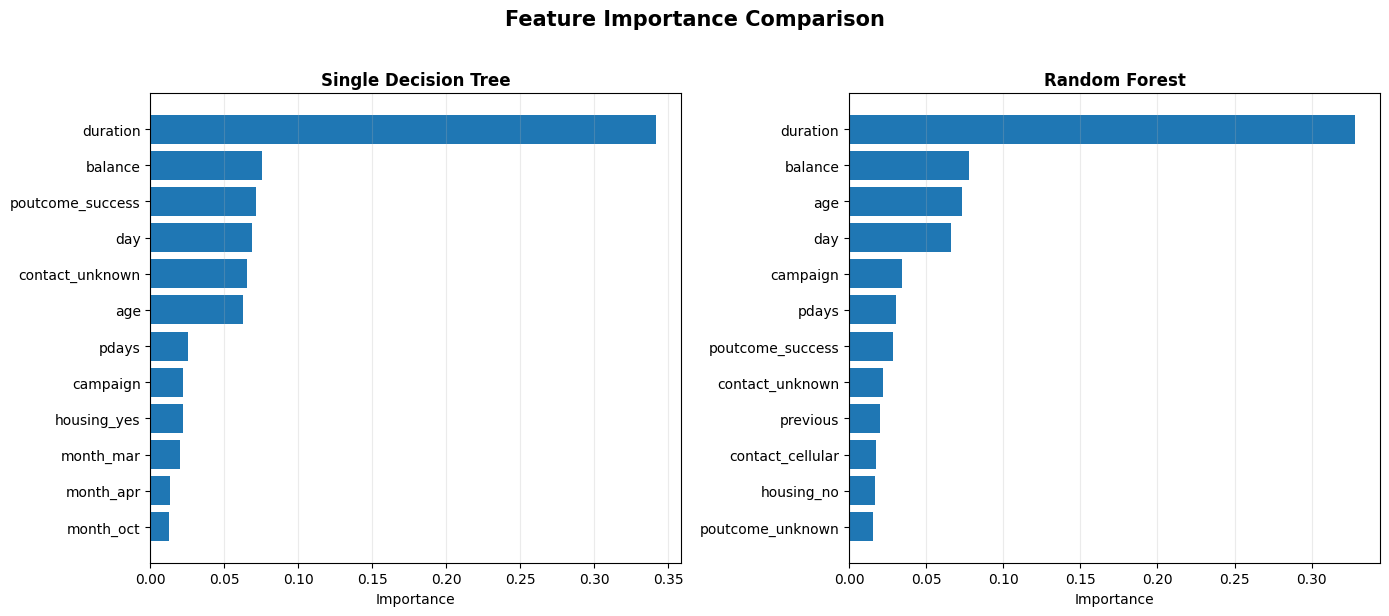

In [10]:
# Plot top feature importances side by side.
# This helps us compare whether both models rely on similar prediction drivers.

top_n = 12

tree_top_features = tree_feature_importance.head(top_n).sort_values("Importance", ascending=True)
forest_top_features = forest_feature_importance.head(top_n).sort_values("Importance", ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=False)

# Single Tree feature importance chart
axes[0].barh(tree_top_features["Feature"], tree_top_features["Importance"])
axes[0].set_title("Single Decision Tree", fontsize=12, weight="bold")
axes[0].set_xlabel("Importance")
axes[0].grid(axis="x", alpha=0.25)

# Random Forest feature importance chart
axes[1].barh(forest_top_features["Feature"], forest_top_features["Importance"])
axes[1].set_title("Random Forest", fontsize=12, weight="bold")
axes[1].set_xlabel("Importance")
axes[1].grid(axis="x", alpha=0.25)

fig.suptitle("Feature Importance Comparison", fontsize=15, weight="bold", y=1.02)
plt.tight_layout()
plt.savefig(figures_dir / "day9_tree_vs_forest_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()


In [11]:
# Compare whether the top features agree between the two models.
# We use top 10 features from each model and calculate their overlap.

tree_top_10 = set(tree_feature_importance.head(10)["Feature"])
forest_top_10 = set(forest_feature_importance.head(10)["Feature"])

common_top_features = sorted(tree_top_10.intersection(forest_top_10))

feature_overlap_summary = pd.DataFrame([{
    "Tree_Top_10_Count": len(tree_top_10),
    "Forest_Top_10_Count": len(forest_top_10),
    "Common_Top_Features": len(common_top_features),
    "Common_Feature_List": ", ".join(common_top_features),
}])

display(feature_overlap_summary)


,Tree_Top_10_Count,Forest_Top_10_Count,Common_Top_Features,Common_Feature_List
0,10,10,8,"age, balance, campaign, contact_unknown, day, ..."


<div style="
  font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Arial, sans-serif;
  line-height: 1.55;
  color: var(--vscode-editor-foreground);
">

<h3 style="margin-bottom: 6px;">Feature importance interpretation guide</h3>

<div style="
  border-left: 4px solid #38bdf8;
  padding: 10px 14px;
  margin: 12px 0;
  background: var(--vscode-editorWidget-background);
  border-radius: 6px;
">
  <b>Important point for understanding:</b><br>
  A single tree may give high importance to one feature because of one strong split.
  A Random Forest averages importance across many trees, so it is usually more stable.
</div>

<p>
If both models agree on the same important features, those variables are likely strong prediction drivers.
If they disagree, Random Forest is often more reliable because the importance is averaged across many trees.
</p>

</div>

<div style="
  font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Arial, sans-serif;
  line-height: 1.55;
  color: var(--vscode-editor-foreground);
">

<h3 style="margin-bottom: 6px;">5. Random Forest size: n_estimators from 10 to 500</h3>

<p>
Increase <code>n_estimators</code> from 10 to 500 in steps of 10
and plot test accuracy. This checks when adding more trees stops giving meaningful gain.
</p>

<div style="
  border-left: 4px solid #38bdf8;
  padding: 10px 14px;
  margin: 12px 0;
  background: var(--vscode-editorWidget-background);
  border-radius: 6px;
">
  <b>Important point for understanding:</b><br>
  More trees usually make the forest more stable, but after a point the improvement becomes very small.
  That point is called stagnation or performance plateau.
</div>

</div>

In [ ]:
# Train Random Forest models with n_estimators from 10 to 500.
# This may take a few minutes because 50 forests are trained.

n_estimators_values = list(range(10, 501, 10))
rf_curve_rows = []

for n_trees in n_estimators_values:

    # Build a Random Forest pipeline for the current number of trees.
    rf_pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=n_trees,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )),
    ])

    # Fit model on training data.
    
    rf_pipeline.fit(X_train, y_train)

    # Predict labels and probabilities on test data.
    
    test_pred = rf_pipeline.predict(X_test)
    test_proba = rf_pipeline.predict_proba(X_test)[:, 1]

    # Store performance for the current forest size.
    
    rf_curve_rows.append({
        "n_estimators": n_trees,
        "Test_Accuracy": accuracy_score(y_test, test_pred),
        "Test_F1": f1_score(y_test, test_pred, zero_division=0),
        "Test_ROC_AUC": roc_auc_score(y_test, test_proba),
    })

    # Progress message helps during longer runs.
    
    if n_trees % 100 == 0:
        print(f"Completed Random Forest with {n_trees} trees")

# Convert results into a DataFrame.

rf_n_estimators_curve = pd.DataFrame(rf_curve_rows)

# Find the best observed test accuracy.

best_rf_accuracy = rf_n_estimators_curve["Test_Accuracy"].max()

# Define stagnation as the first tree count within 0.2 percentage points
# of the best observed accuracy.

stagnation_threshold = best_rf_accuracy - 0.002

stagnation_candidates = rf_n_estimators_curve[
    rf_n_estimators_curve["Test_Accuracy"] >= stagnation_threshold
]

stagnation_point = int(stagnation_candidates.iloc[0]["n_estimators"])

print(f"Best test accuracy: {best_rf_accuracy:.4f}")
print(f"Stagnation point estimate: around {stagnation_point} trees")

display(rf_n_estimators_curve.tail())


Completed Random Forest with 100 trees
Completed Random Forest with 200 trees
Completed Random Forest with 300 trees
Completed Random Forest with 400 trees
Completed Random Forest with 500 trees
Best test accuracy: 0.8621
Stagnation point estimate: around 100 trees


,n_estimators,Test_Accuracy,Test_F1,Test_ROC_AUC
45,460,0.856695,0.854015,0.920586
46,470,0.857143,0.854670,0.920597
47,480,0.857143,0.854537,0.920598
48,490,0.856247,0.853625,0.920615
49,500,0.856695,0.854281,0.920619


<div style="
  font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Arial, sans-serif;
  line-height: 1.55;
  color: var(--vscode-editor-foreground);
">

<h3 style="margin-bottom: 6px;">Important Point: Random Forest Tree Stability</h3>

<p>
This section tests how Random Forest performance changes when we increase the number of trees from
<b>10 to 500</b>. In Random Forest, <code>n_estimators</code> means the number of decision trees inside the forest.
</p>

<table style="border-collapse: collapse; width: 100%; margin: 10px 0;">
  <thead>
    <tr>
      <th style="text-align: left; border-bottom: 1px solid #888; padding: 6px;">Code part</th>
      <th style="text-align: left; border-bottom: 1px solid #888; padding: 6px;">Meaning</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td style="padding: 6px;"><code>range(10, 501, 10)</code></td>
      <td style="padding: 6px;">Creates forest sizes from 10 trees to 500 trees in steps of 10.</td>
    </tr>
    <tr>
      <td style="padding: 6px;"><code>n_estimators=n_trees</code></td>
      <td style="padding: 6px;">Sets the number of trees for the current Random Forest model.</td>
    </tr>
    <tr>
      <td style="padding: 6px;"><code>Test_Accuracy</code>, <code>Test_F1</code>, <code>Test_ROC_AUC</code></td>
      <td style="padding: 6px;">Stores the test performance for each forest size.</td>
    </tr>
    <tr>
      <td style="padding: 6px;"><code>stagnation_point</code></td>
      <td style="padding: 6px;">Finds the first tree count where accuracy is already very close to the best observed accuracy.</td>
    </tr>
  </tbody>
</table>

<div style="
  border-left: 4px solid #38bdf8;
  padding: 10px 14px;
  margin: 12px 0;
  background: var(--vscode-editorWidget-background);
  border-radius: 6px;
">
  <b>Key idea:</b><br>
  More trees usually make Random Forest more stable, but after a certain point the improvement becomes very small.
  This is called the <b>stagnation point</b>.
</div>

<p>
The goal is not to blindly use the largest forest. Instead, we want to identify where adding more trees stops giving
meaningful improvement. This helps us choose a model that is accurate, stable, and not unnecessarily slow.
</p>

<p>
From a business point of view, this answers:
<b>How many trees are enough before extra training time gives little extra value?</b>
</p>

</div>

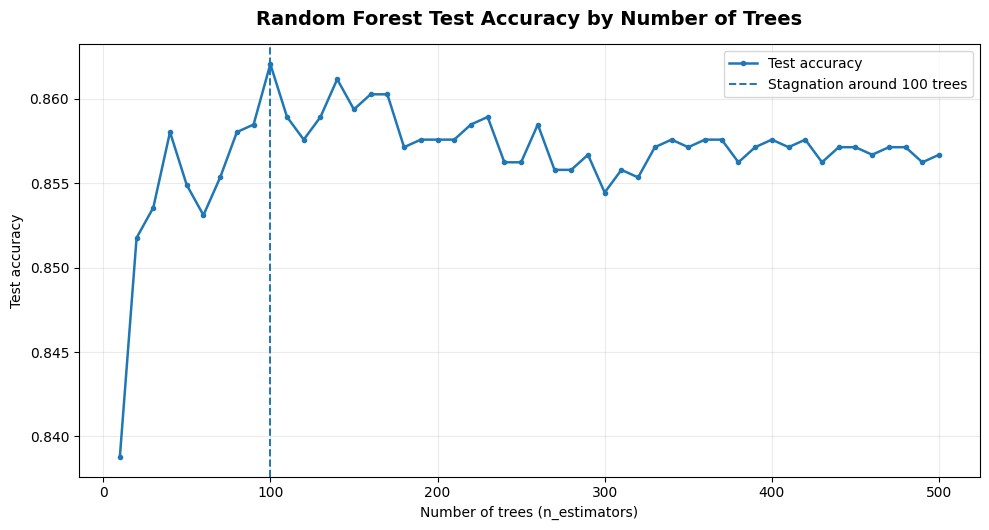

In [13]:
# Plot Random Forest test accuracy against number of trees.

plt.figure(figsize=(10, 5.4))

plt.plot(
    rf_n_estimators_curve["n_estimators"],
    rf_n_estimators_curve["Test_Accuracy"],
    marker="o",
    linewidth=1.8,
    markersize=3,
    label="Test accuracy",
)

# Add vertical line at estimated stagnation point.
plt.axvline(
    stagnation_point,
    linestyle="--",
    linewidth=1.4,
    label=f"Stagnation around {stagnation_point} trees",
)

plt.title("Random Forest Test Accuracy by Number of Trees", fontsize=14, weight="bold", pad=14)
plt.xlabel("Number of trees (n_estimators)")
plt.ylabel("Test accuracy")
plt.grid(alpha=0.25)
plt.legend()

plt.tight_layout()
plt.savefig(figures_dir / "day9_rf_n_estimators_accuracy_curve.png", dpi=150, bbox_inches="tight")
plt.show()


<div style="
  font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Arial, sans-serif;
  line-height: 1.55;
  color: var(--vscode-editor-foreground);
">

<h3 style="margin-bottom: 6px;">Conclusion: Random Forest Tree Stability</h3>

<p>
The Random Forest stability test trained models with <b>10 to 500 trees</b> in steps of 10.
The best observed test accuracy was <b>86.21%</b>.
</p>

<div style="
  border-left: 4px solid #22c55e;
  padding: 10px 14px;
  margin: 12px 0;
  background: var(--vscode-editorWidget-background);
  border-radius: 6px;
">
  <b>Main result:</b><br>
  The model performance starts to stagnate at around <b>100 trees</b>.
  This means that 100 trees are already enough to reach near-best accuracy for this dataset.
</div>

<p>
After 100 trees, adding more trees up to 500 does not meaningfully improve test accuracy.
The last tested models, from around 460 to 500 trees, show test accuracy around <b>85.6% to 85.7%</b>,
which is slightly below the best observed value.
</p>

<p>
The ROC-AUC remains very stable at around <b>0.9206</b> for the larger forests.
This means that larger forests still separate subscribers from non-subscribers well,
but they do not improve the final classification accuracy enough to justify the extra complexity.
</p>

<div style="
  border-left: 4px solid #38bdf8;
  padding: 10px 14px;
  margin: 12px 0;
  background: var(--vscode-editorWidget-background);
  border-radius: 6px;
">
  <b>Important point for understanding:</b><br>
  More trees usually make Random Forest more stable, but more trees do not always mean better test accuracy.
  After the stagnation point, the model becomes slower without giving meaningful performance gain.
</div>

<p>
From a business point of view, a Random Forest with around <b>100 trees</b> is a practical choice.
It gives strong predictive performance while avoiding unnecessary training time and model complexity.
</p>

</div>

<div style="
  font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Arial, sans-serif;
  line-height: 1.55;
  color: var(--vscode-editor-foreground);
">

<h3 style="margin-bottom: 6px;">n_estimators interpretation guide</h3>

<p>
After running the curve, look for the point where the line becomes mostly flat.
That means adding more trees costs extra training time but gives little extra accuracy.
</p>

<div style="
  border-left: 4px solid #f59e0b;
  padding: 10px 14px;
  margin: 12px 0;
  background: var(--vscode-editorWidget-background);
  border-radius: 6px;
">
  <b>Business interpretation:</b><br>
  If 150 trees and 500 trees perform almost the same, the smaller forest may be better for production
  because it is faster and simpler to maintain.
</div>

</div>

<div style="
  font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Arial, sans-serif;
  line-height: 1.55;
  color: var(--vscode-editor-foreground);
">

<h3 style="margin-bottom: 6px;">6. out-of-bag (OOB) score: built-in validation from bootstrap leftovers</h3>

<p>
OOB means out-of-bag. For each tree, some rows are not selected in that tree's bootstrap sample.
Those rows can be used as a built-in validation check.
</p>

</div>

In [ ]:
# Train a Random Forest with OOB scoring enabled.
# OOB scoring works only when bootstrap=True, which is the default for Random Forest.

rf_oob_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=300,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        bootstrap=True, # Bootstrap applied for Bagging
        oob_score=True,
    )),
])

# Fit the OOB Random Forest.

rf_oob_pipeline.fit(X_train, y_train)

# Extract OOB score from the fitted Random Forest model.

rf_oob_score = rf_oob_pipeline.named_steps["model"].oob_score_

# Evaluate on the real test set for comparison.

rf_oob_test_pred = rf_oob_pipeline.predict(X_test)
rf_oob_test_proba = rf_oob_pipeline.predict_proba(X_test)[:, 1]

rf_oob_summary = pd.DataFrame([{
    "Model": "Random Forest OOB (300 trees)",
    "OOB_Accuracy": rf_oob_score,
    "Test_Accuracy": accuracy_score(y_test, rf_oob_test_pred),
    "Test_F1": f1_score(y_test, rf_oob_test_pred, zero_division=0),
    "Test_ROC_AUC": roc_auc_score(y_test, rf_oob_test_proba),
}])

rf_oob_summary_rounded = rf_oob_summary.copy()
for col in ["OOB_Accuracy", "Test_Accuracy", "Test_F1", "Test_ROC_AUC"]:
    rf_oob_summary_rounded[col] = rf_oob_summary_rounded[col].round(4)

display(rf_oob_summary_rounded)


,Model,OOB_Accuracy,Test_Accuracy,Test_F1,Test_ROC_AUC
0,Random Forest OOB (300 trees),0.8527,0.8545,0.8518,0.9205


<div style="
  font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Arial, sans-serif;
  line-height: 1.55;
  color: var(--vscode-editor-foreground);
">

<h3 style="margin-bottom: 6px;">Conclusion: Out-of-Bag Evaluation</h3>

<p>
The Random Forest with <b>300 trees</b> achieved an <b>OOB accuracy of 85.27%</b>
and a <b>test accuracy of 85.45%</b>.
</p>

<div style="
  border-left: 4px solid #22c55e;
  padding: 10px 14px;
  margin: 12px 0;
  background: var(--vscode-editorWidget-background);
  border-radius: 6px;
">
  <b>Main result:</b><br>
  The OOB accuracy and test accuracy are very close.
  This means the out-of-bag estimate is a reliable internal validation signal for this Random Forest model.
</div>

<p>
Out-of-bag evaluation works because each tree is trained on a bootstrap sample.
Rows that are not selected for a tree are left out and can be used to test that tree.
This gives Random Forest a useful built-in validation method without needing a separate validation split.
</p>

<p>
The model also achieved a <b>test F1-score of 85.18%</b> and a <b>test ROC-AUC of 92.05%</b>.
This confirms that the Random Forest separates likely subscribers from non-subscribers well.
</p>

<div style="
  border-left: 4px solid #38bdf8;
  padding: 10px 14px;
  margin: 12px 0;
  background: var(--vscode-editorWidget-background);
  border-radius: 6px;
">
  <b>Important point for understanding:</b><br>
  OOB evaluation is useful for Random Forest because every tree leaves out some rows during bootstrap sampling.
  Those left-out rows act like a small internal test set.
</div>

<p>
From a business point of view, the close match between OOB accuracy and test accuracy gives confidence that the Random Forest model is stable and not only performing well by chance on one test split.
</p>

</div>

<div style="
  font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Arial, sans-serif;
  line-height: 1.55;
  color: var(--vscode-editor-foreground);
">

<h3 style="margin-bottom: 6px;">7. RSM experiment: changing max_features</h3>

<p>
Random Subspace Method controls how many features are available to each split.
In scikit-learn Random Forest, this is mainly controlled through <code>max_features</code>.
</p>

<div style="
  border-left: 4px solid #38bdf8;
  padding: 10px 14px;
  margin: 12px 0;
  background: var(--vscode-editorWidget-background);
  border-radius: 6px;
">
  <b>Important point for understanding:</b><br>
  Smaller feature subsets can make trees more diverse, but too few features may weaken each tree.
  The goal is a good balance between diversity and predictive strength.
</div>

</div>

<div style="
  font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Arial, sans-serif;
  line-height: 1.55;
  color: var(--vscode-editor-foreground);
">

<h3 style="margin-bottom: 6px;">Important Point: Random Subspace Method with max_features</h3>

<p>
This section compares different <code>max_features</code> settings in a Random Forest model.
The parameter <code>max_features</code> controls how many features each tree split is allowed to consider.
This is the practical implementation of the <b>Random Subspace Method</b>.
</p>

<table style="border-collapse: collapse; width: 100%; margin: 10px 0;">
  <thead>
    <tr>
      <th style="text-align: left; border-bottom: 1px solid #888; padding: 6px;">Setting</th>
      <th style="text-align: left; border-bottom: 1px solid #888; padding: 6px;">Meaning</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td style="padding: 6px;"><code>sqrt</code></td>
      <td style="padding: 6px;">Each split sees roughly the square root of the total number of features.</td>
    </tr>
    <tr>
      <td style="padding: 6px;"><code>log2</code></td>
      <td style="padding: 6px;">Each split sees roughly log2 of the total number of features.</td>
    </tr>
    <tr>
      <td style="padding: 6px;"><code>0.5</code></td>
      <td style="padding: 6px;">Each split sees 50% of the available features.</td>
    </tr>
    <tr>
      <td style="padding: 6px;"><code>None</code></td>
      <td style="padding: 6px;">Each split can see all features, so feature-level randomness is reduced.</td>
    </tr>
  </tbody>
</table>

<div style="
  border-left: 4px solid #38bdf8;
  padding: 10px 14px;
  margin: 12px 0;
  background: var(--vscode-editorWidget-background);
  border-radius: 6px;
">
  <b>Key idea:</b><br>
  Random Forest works best when trees are not all identical.
  <code>max_features</code> creates feature-level randomness, so different trees can learn different patterns.
</div>

<p>
The code trains one Random Forest for each <code>max_features</code> option.
For every model, it calculates <b>test accuracy</b>, <b>F1-score</b>, and <b>ROC-AUC</b>.
The final table is sorted by <b>F1-score</b>, so the strongest setting appears at the top.
</p>

<p>
From a business point of view, this experiment helps us find the best balance between
tree diversity and prediction strength. Too little randomness can make trees too similar,
while too much randomness can make each tree weaker.
</p>

</div>

In [ ]:
# Compare different max_features settings.
# This shows how random feature selection affects Random Forest performance.

max_features_options = ["sqrt", "log2", 0.5, None]
max_features_rows = []

for max_features_value in max_features_options:

    # Build Random Forest with the current max_features setting.
    rf_rsm_pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=200,
            max_features=max_features_value, # Random Space Method Applied
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )),
    ])

    # Train model.
    rf_rsm_pipeline.fit(X_train, y_train)

    # Predict on test data.
    rsm_pred = rf_rsm_pipeline.predict(X_test)
    rsm_proba = rf_rsm_pipeline.predict_proba(X_test)[:, 1]

    # Store results.
    max_features_rows.append({
        "max_features": str(max_features_value),
        "Test_Accuracy": accuracy_score(y_test, rsm_pred),
        "Test_F1": f1_score(y_test, rsm_pred, zero_division=0),
        "Test_ROC_AUC": roc_auc_score(y_test, rsm_proba),
    })

rf_max_features_experiment = pd.DataFrame(max_features_rows).sort_values("Test_F1", ascending=False)

rf_max_features_experiment_rounded = rf_max_features_experiment.copy()
for col in ["Test_Accuracy", "Test_F1", "Test_ROC_AUC"]:
    rf_max_features_experiment_rounded[col] = rf_max_features_experiment_rounded[col].round(4)

display(rf_max_features_experiment_rounded)


,max_features,Test_Accuracy,Test_F1,Test_ROC_AUC
2,0.5,0.8594,0.8575,0.9258
0,sqrt,0.8576,0.8552,0.9200
3,None,0.8567,0.8543,0.9210
1,log2,0.8545,0.8515,0.9176


<div style="
  font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Arial, sans-serif;
  line-height: 1.55;
  color: var(--vscode-editor-foreground);
">

<h3 style="margin-bottom: 6px;">Conclusion: Random Subspace Method / max_features</h3>

<p>
This experiment compares different <code>max_features</code> settings in Random Forest.
The <code>max_features</code> parameter controls how many features each tree is allowed to consider at each split.
This is the practical implementation of the <b>Random Subspace Method</b>.
</p>

<div style="
  border-left: 4px solid #22c55e;
  padding: 10px 14px;
  margin: 12px 0;
  background: var(--vscode-editorWidget-background);
  border-radius: 6px;
">
  <b>Best result:</b><br>
  <code>max_features = 0.5</code> performed best, with
  <b>85.94% test accuracy</b>, <b>85.75% F1-score</b>, and <b>92.58% ROC-AUC</b>.
</div>

<p>
This result shows that allowing each split to consider around <b>50% of the available features</b>
gave the best balance between randomness and useful information.
The trees were different enough to reduce correlation, but still had enough features available to make strong decisions.
</p>

<table style="border-collapse: collapse; width: 100%; margin: 10px 0;">
  <thead>
    <tr>
      <th style="text-align: left; border-bottom: 1px solid #888; padding: 6px;">Setting</th>
      <th style="text-align: left; border-bottom: 1px solid #888; padding: 6px;">Interpretation</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td style="padding: 6px;"><code>sqrt</code></td>
      <td style="padding: 6px;">Good default setting, but slightly weaker than 0.5 here.</td>
    </tr>
    <tr>
      <td style="padding: 6px;"><code>log2</code></td>
      <td style="padding: 6px;">Uses fewer features per split and produced the weakest result in this experiment.</td>
    </tr>
    <tr>
      <td style="padding: 6px;"><code>0.5</code></td>
      <td style="padding: 6px;">Best balance between feature randomness and predictive strength.</td>
    </tr>
    <tr>
      <td style="padding: 6px;"><code>None</code></td>
      <td style="padding: 6px;">Allows all features at each split, reducing feature-level randomness.</td>
    </tr>
  </tbody>
</table>

<div style="
  border-left: 4px solid #38bdf8;
  padding: 10px 14px;
  margin: 12px 0;
  background: var(--vscode-editorWidget-background);
  border-radius: 6px;
">
  <b>Important point for understanding:</b><br>
  Random Forest becomes stronger when trees are not too similar.
  The Random Subspace Method helps by forcing trees to consider different feature subsets.
</div>

<p>
From a business point of view, <code>max_features = 0.5</code> is the strongest configuration tested here.
It gives the best predictive quality while preserving the Random Forest idea of diverse trees.
</p>

</div>

| Setting  | Meaning                                               |
| -------- | ----------------------------------------------------- |
| `"sqrt"` | Each split sees roughly square root of total features |
| `"log2"` | Each split sees roughly log2 of total features        |
| `0.5`    | Each split sees 50% of the features                   |
| `None`   | Each split can see all features                       |


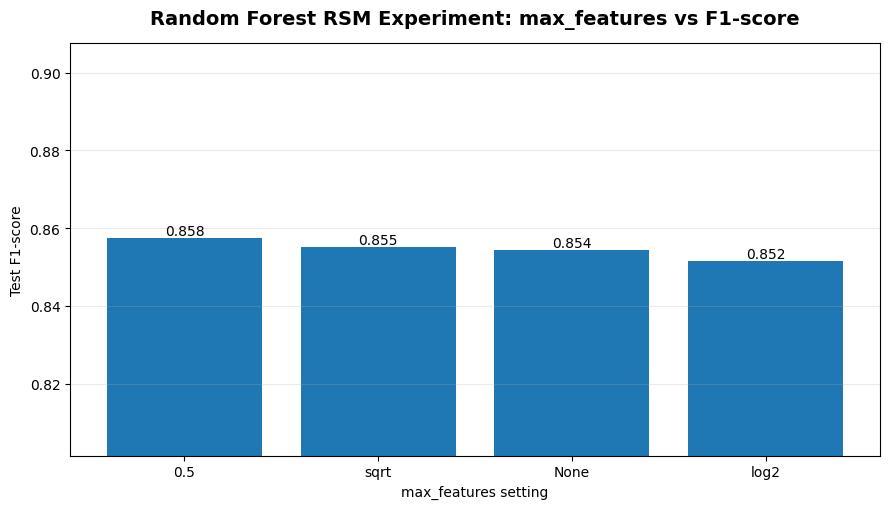

In [16]:
# Plot RSM / max_features experiment results.

plt.figure(figsize=(9, 5.2))

bars = plt.bar(
    rf_max_features_experiment_rounded["max_features"],
    rf_max_features_experiment_rounded["Test_F1"],
)

plt.title("Random Forest RSM Experiment: max_features vs F1-score", fontsize=14, weight="bold", pad=14)
plt.xlabel("max_features setting")
plt.ylabel("Test F1-score")
plt.ylim(
    max(0, rf_max_features_experiment_rounded["Test_F1"].min() - 0.05),
    min(1.05, rf_max_features_experiment_rounded["Test_F1"].max() + 0.05),
)
plt.grid(axis="y", alpha=0.25)

# Add labels on each bar.
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.3f}",
        ha="center",
        va="bottom",
        fontsize=10,
    )

plt.tight_layout()
plt.savefig(figures_dir / "day9_rf_max_features_rsm_experiment.png", dpi=150, bbox_inches="tight")
plt.show()


<div style="
  font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Arial, sans-serif;
  line-height: 1.55;
  color: var(--vscode-editor-foreground);
">

<h3 style="margin-bottom: 6px;">8. Random Forest confusion matrix</h3>

<p>
We inspect the confusion matrix for the main Random Forest model.
This allows comparison against the Logistic Regression confusion matrix from Notebook 2.
</p>

</div>

Classification report — Random Forest (100 trees):
                precision    recall  f1-score   support

Not subscribed       0.90      0.84      0.86      1175
    Subscribed       0.83      0.89      0.86      1058

      accuracy                           0.86      2233
     macro avg       0.86      0.86      0.86      2233
  weighted avg       0.86      0.86      0.86      2233



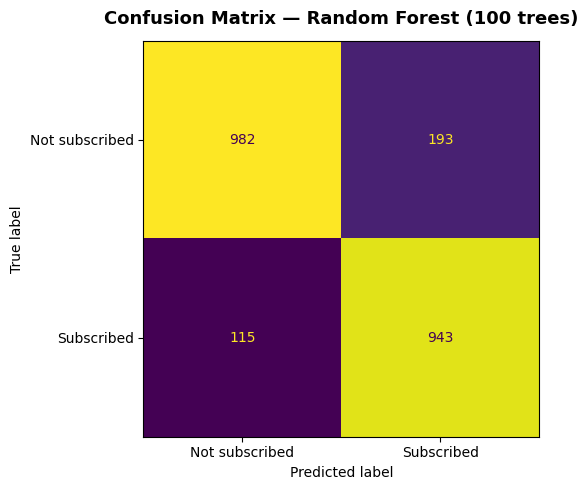

In [17]:
# Generate predictions for the main Random Forest model.
forest_test_pred = random_forest_100_pipeline.predict(X_test)

# Print classification report for detailed class-level evaluation.
print("Classification report — Random Forest (100 trees):")
print(
    classification_report(
        y_test,
        forest_test_pred,
        target_names=["Not subscribed", "Subscribed"],
        zero_division=0,
    )
)

# Create confusion matrix.
forest_cm = confusion_matrix(y_test, forest_test_pred)

forest_cm_display = ConfusionMatrixDisplay(
    confusion_matrix=forest_cm,
    display_labels=["Not subscribed", "Subscribed"],
)

fig, ax = plt.subplots(figsize=(6, 5))

forest_cm_display.plot(
    ax=ax,
    values_format=",d",
    colorbar=False,
)

plt.title("Confusion Matrix — Random Forest (100 trees)", fontsize=13, weight="bold", pad=12)
plt.tight_layout()
plt.savefig(figures_dir / "day9_random_forest_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()


<div style="
  font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Arial, sans-serif;
  line-height: 1.55;
  color: var(--vscode-editor-foreground);
">

<h3 style="margin-bottom: 6px;">9. Save Notebook 3 outputs</h3>

<p>
The outputs from this notebook will be reused in later notebooks for stacking,
blending, and final MVD proof.
</p>

</div>

In [18]:
# Save result tables for later notebooks and final documentation.

tree_forest_results_rounded.to_csv(
    reports_dir / "day9_tree_vs_random_forest_results.csv",
    index=False,
)

tree_feature_importance.to_csv(
    reports_dir / "day9_single_tree_feature_importance.csv",
    index=False,
)

forest_feature_importance.to_csv(
    reports_dir / "day9_random_forest_feature_importance.csv",
    index=False,
)

feature_overlap_summary.to_csv(
    reports_dir / "day9_feature_importance_overlap_summary.csv",
    index=False,
)

rf_n_estimators_curve.to_csv(
    reports_dir / "day9_rf_n_estimators_curve.csv",
    index=False,
)

rf_oob_summary_rounded.to_csv(
    reports_dir / "day9_rf_oob_summary.csv",
    index=False,
)

rf_max_features_experiment_rounded.to_csv(
    reports_dir / "day9_rf_max_features_experiment.csv",
    index=False,
)

# Save trained model pipelines.
joblib.dump(
    single_tree_pipeline,
    models_dir / "day9_single_decision_tree_pipeline.joblib",
)

joblib.dump(
    random_forest_100_pipeline,
    models_dir / "day9_random_forest_100_pipeline.joblib",
)

joblib.dump(
    rf_oob_pipeline,
    models_dir / "day9_random_forest_oob_pipeline.joblib",
)

# Save a compact notebook summary for downstream notebooks.
notebook3_summary = pd.DataFrame([{
    "Single_Tree_Test_Accuracy": tree_forest_results.loc[
        tree_forest_results["Model"] == "Single Decision Tree", "Test_Accuracy"
    ].iloc[0],
    "Random_Forest_Test_Accuracy": tree_forest_results.loc[
        tree_forest_results["Model"] == "Random Forest (100 trees)", "Test_Accuracy"
    ].iloc[0],
    "Single_Tree_Test_F1": tree_forest_results.loc[
        tree_forest_results["Model"] == "Single Decision Tree", "Test_F1"
    ].iloc[0],
    "Random_Forest_Test_F1": tree_forest_results.loc[
        tree_forest_results["Model"] == "Random Forest (100 trees)", "Test_F1"
    ].iloc[0],
    "Random_Forest_Test_ROC_AUC": tree_forest_results.loc[
        tree_forest_results["Model"] == "Random Forest (100 trees)", "Test_ROC_AUC"
    ].iloc[0],
    "Estimated_n_estimators_Stagnation_Point": stagnation_point,
    "Random_Forest_OOB_Accuracy": rf_oob_score,
    "Best_max_features_by_F1": rf_max_features_experiment.iloc[0]["max_features"],
}])

notebook3_summary.to_csv(
    reports_dir / "day9_notebook3_summary.csv",
    index=False,
)

print("Notebook 3 outputs saved successfully.")
print(f"- {reports_dir / 'day9_tree_vs_random_forest_results.csv'}")
print(f"- {reports_dir / 'day9_single_tree_feature_importance.csv'}")
print(f"- {reports_dir / 'day9_random_forest_feature_importance.csv'}")
print(f"- {reports_dir / 'day9_rf_n_estimators_curve.csv'}")
print(f"- {reports_dir / 'day9_rf_oob_summary.csv'}")
print(f"- {reports_dir / 'day9_rf_max_features_experiment.csv'}")
print(f"- {models_dir / 'day9_single_decision_tree_pipeline.joblib'}")
print(f"- {models_dir / 'day9_random_forest_100_pipeline.joblib'}")
print(f"- {models_dir / 'day9_random_forest_oob_pipeline.joblib'}")

display(notebook3_summary.round(4))


Notebook 3 outputs saved successfully.
- reports/day9_tree_vs_random_forest_results.csv
- reports/day9_single_tree_feature_importance.csv
- reports/day9_random_forest_feature_importance.csv
- reports/day9_rf_n_estimators_curve.csv
- reports/day9_rf_oob_summary.csv
- reports/day9_rf_max_features_experiment.csv
- models/day9_single_decision_tree_pipeline.joblib
- models/day9_random_forest_100_pipeline.joblib
- models/day9_random_forest_oob_pipeline.joblib


,Single_Tree_Test_Accuracy,Random_Forest_Test_Accuracy,Single_Tree_Test_F1,Random_Forest_Test_F1,Random_Forest_Test_ROC_AUC,Estimated_n_estimators_Stagnation_Point,Random_Forest_OOB_Accuracy,Best_max_features_by_F1
0,0.7944,0.8621,0.7807,0.8596,0.9193,100,0.8527,0.5


<div style="
  font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Arial, sans-serif;
  line-height: 1.55;
  color: var(--vscode-editor-foreground);
">

<h3 style="margin-bottom: 6px;">Final Conclusion: Notebook 3</h3>

<p>
Notebook 3 implemented the practical Bagging and Random Forest part of Day 9.
It compared a full single Decision Tree against a Random Forest, inspected feature importance,
tested the effect of forest size, evaluated OOB scoring, and examined the Random Subspace Method
through <code>max_features</code>.
</p>

<div style="
  border-left: 4px solid #22c55e;
  padding: 10px 14px;
  margin: 12px 0;
  background: var(--vscode-editorWidget-background);
  border-radius: 6px;
">
  <b>Main learning:</b><br>
  Random Forest combines different row samples, different feature subsets, and many decision trees.
  This usually gives more stable predictions than one single Decision Tree.
</div>

<p>
The feature importance comparison helps us understand whether the single tree and forest agree
on the most important customer/campaign drivers. The Random Forest importance is usually more stable
because it is averaged across many trees.
</p>

<p>
The <code>n_estimators</code> curve shows when adding more trees stops giving meaningful test accuracy gain.
This is important because a larger forest is not always worth the extra training time.
</p>

<div style="
  border-left: 4px solid #38bdf8;
  padding: 10px 14px;
  margin: 12px 0;
  background: var(--vscode-editorWidget-background);
  border-radius: 6px;
">
  <b>Next notebook:</b><br>
  Notebook 4 will move from Random Forest to stacking. We will compare different base learners using
  cross-validation and then build a <code>StackingClassifier</code> with Logistic Regression and Random Forest
  meta-models.
</div>

</div>